Exploratory Data Analysis on SCMS Delivery Dataset

# **Project Name**    -
Exploratory Data Analysis on SCMS Delivery Dataset


##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on analyzing supply chain and logistics data to improve delivery performance, reduce costs, and enhance operational efficiency.

The dataset consists of shipment-related information such as country, vendor, shipment mode, lead time, item value, weight, and freight cost. The primary goal of this analysis is to identify inefficiencies in delivery performance and optimize logistics strategies.

The first step involved data cleaning and preprocessing. Column names were standardized, and missing values were handled appropriately. Irrelevant columns such as dosage were removed due to high missing values and lack of analytical importance. Non-numeric columns like weight and freight cost were converted into numeric format for proper analysis. Date columns were processed to ensure consistency, although some inconsistencies in date sequencing were identified. Therefore, the existing lead_time column was used as a reliable measure of delivery duration.

Feature engineering was performed to enhance the dataset. A new variable called delivery_days was derived from lead_time, and an on_time_delivery flag was created using a threshold of 30 days. Additionally, a new metric called freight_per_kg was calculated to evaluate cost efficiency.

Exploratory Data Analysis (EDA) was conducted using various visualizations. Histograms and KDE plots revealed that both freight cost and lead time are right-skewed, indicating the presence of outliers. Boxplots showed variations in delivery performance across different shipment modes, highlighting inefficiencies in certain modes. Scatter plots indicated weak relationships between freight cost and delivery speed, suggesting that higher cost does not guarantee faster delivery. Correlation heatmaps further confirmed that cost is strongly influenced by weight and item value, while lead time has weak correlation with other variables.

Vendor and country-level analysis revealed that certain vendors and regions have higher average lead times and freight costs, indicating opportunities for optimization. Shipment mode analysis showed that air transport is frequently used, but may not always be cost-effective.

Key performance indicators (KPIs) such as total shipments, average lead time, on-time delivery percentage, and total freight cost were calculated to evaluate overall performance.

The insights from this project highlight that logistics inefficiencies exist in terms of cost management and delivery performance. High-cost shipments do not always result in faster delivery, and variability in lead time indicates inconsistency in operations.

Overall, this analysis provides actionable insights to improve delivery speed, reduce costs, optimize shipment modes, and enhance vendor performance. These improvements can lead to better customer satisfaction and increased business efficiency.

# **GitHub Link -**

GitHub: https://github.com/suninov15-glitch/Fed-Ex--

# **Problem Statement**


FedEx Logistics manages high-volume global shipments where delays, long lead times, and rising freight costs can significantly impact service reliability and margins.

The objective of this analysis is to evaluate delivery performance, lead-time efficiency, and freight cost behavior across shipment modes, vendors, and regions. The goal is to identify bottlenecks, cost drivers, and improvement opportunities.

The insights derived from this analysis will support data-driven decisions to enhance on-time delivery, optimize transportation modes, and reduce overall logistics costs.

#### **Define Your Business Objective?**

The objective is to analyze FedEx logistics shipment data to identify delivery inefficiencies, cost drivers, and operational bottlenecks.

This includes improving on-time delivery performance, optimizing shipment modes, reducing freight costs, enhancing vendor performance, and ensuring more efficient and cost-effective logistics operations.

Ultimately, the goal is to improve customer satisfaction and overall supply chain efficiency.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset Loading

In [2]:
df = pd.read_csv("SCMS_Delivery_History_Dataset.csv ")
print( " the dataset has been loaded")

 the dataset has been loaded


### Dataset First View

### Dataset Rows & Columns count

In [3]:
pd.set_option("display.max_columns", None)
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [4]:
# Get number of rows and columns
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 10324
Number of Columns: 33


### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

#### Duplicate Values

In [6]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Dataset Duplicate Value C# Missing values
df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

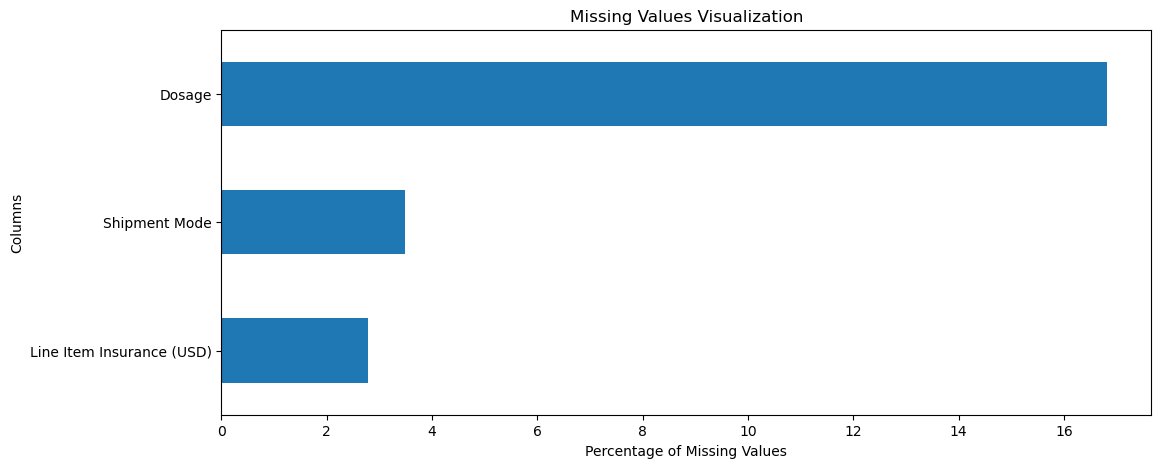

In [8]:
import matplotlib.pyplot as plt

# visualize the missing values
missing = df.isnull().mean() * 100
missing = missing[missing > 0]

plt.figure(figsize=(12,5))
missing.sort_values().plot(kind="barh")

plt.xlabel("Percentage of Missing Values")
plt.ylabel("Columns")
plt.title("Missing Values Visualization")

plt.show()

In [11]:
df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(0)

In [12]:
df['Shipment Mode'] = df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0])

In [19]:
df = df.drop(columns=['Dosage'], errors='ignore')

In [27]:
print(df.columns.tolist())

['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country', 'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode', 'pq_first_sent_to_client_date', 'po_sent_to_vendor_date', 'scheduled_delivery_date', 'delivered_to_client_date', 'delivery_recorded_date', 'product_group', 'sub_classification', 'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity', 'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site', 'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)', 'line_item_insurance_(usd)']


In [31]:
df['delivered_to_client_date'] = pd.to_datetime(
    df['delivered_to_client_date'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)

df['po_sent_to_vendor_date'] = pd.to_datetime(
    df['po_sent_to_vendor_date'],
    errors='coerce',
    format='mixed',
    dayfirst=True
)

In [33]:
df = df[df['lead_time'] >= 0]

In [34]:
df = df[df['lead_time'] <= 365]

In [35]:
df['lead_time'].describe()

count    4557.000000
mean      103.572745
std        74.446826
min         0.000000
25%        50.000000
50%        91.000000
75%       142.000000
max       365.000000
Name: lead_time, dtype: float64

In [20]:
df.isnull().sum()

ID                              0
Project Code                    0
PQ #                            0
PO / SO #                       0
ASN/DN #                        0
Country                         0
Managed By                      0
Fulfill Via                     0
Vendor INCO Term                0
Shipment Mode                   0
PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
Product Group                   0
Sub Classification              0
Vendor                          0
Item Description                0
Molecule/Test Type              0
Brand                           0
Dosage Form                     0
Unit of Measure (Per Pack)      0
Line Item Quantity              0
Line Item Value                 0
Pack Price                      0
Unit Price                      0
Manufacturing Site              0
First Line Designation          0
Weight (Kilogr

### What did you know about your dataset?

The FedEx dataset comprises 10,324 records across 33 columns, the dataset had missing values in shipment mode,dosage, and Line Item Insurance (USD).some columns had inconsistent data like text in numeric fields. I handled missing values, removed irrelevant columns, and cleaned the data to make it ready for analysis. the dataset contains both categorical and numerical variables, and after handling missing and inconsistent data, it was prepared for further exploratory data analysis to derive insights related to delivery performance and cost efficiency.

## ***2. Understanding Your Variables***

In [21]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")  # shows number of unique values #

ID : 10324
Project Code : 142
PQ # : 1237
PO / SO # : 6233
ASN/DN # : 7030
Country : 43
Managed By : 4
Fulfill Via : 2
Vendor INCO Term : 8
Shipment Mode : 4
PQ First Sent to Client Date : 765
PO Sent to Vendor Date : 897
Scheduled Delivery Date : 2006
Delivered to Client Date : 2093
Delivery Recorded Date : 2042
Product Group : 5
Sub Classification : 6
Vendor : 73
Item Description : 184
Molecule/Test Type : 86
Brand : 48
Dosage Form : 17
Unit of Measure (Per Pack) : 31
Line Item Quantity : 5065
Line Item Value : 8741
Pack Price : 1175
Unit Price : 183
Manufacturing Site : 88
First Line Designation : 2
Weight (Kilograms) : 4688
Freight Cost (USD) : 6733
Line Item Insurance (USD) : 6722


### Variables Description

In [22]:
df.describe(include = 'all')

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10324,10324,10324,10324,10324.000000
unique,NaN,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,17,NaN,NaN,NaN,NaN,NaN,88,2,4688,6733,NaN
top,NaN,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,Tablet,NaN,NaN,NaN,NaN,NaN,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost,NaN
freq,NaN,768,2681,67,54,1406,10265,5404,5404,6473,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,3532,NaN,NaN,NaN,NaN,NaN,3172,7030,1507,1442,NaN
mean,51098.968229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,NaN,NaN,NaN,NaN,233.442523
std,31944.332496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,NaN,NaN,NaN,NaN,494.765813
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000e+00,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,12795.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,408.000000,4.314593e+03,4.120000,0.080000,NaN,NaN,NaN,NaN,5.242500
50%,57540.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,NaN,NaN,NaN,NaN,42.815000
75%,83648.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,NaN,NaN,NaN,NaN,241.750000


In [23]:
df.dtypes

ID                                int64
Project Code                     object
PQ #                             object
PO / SO #                        object
ASN/DN #                         object
Country                          object
Managed By                       object
Fulfill Via                      object
Vendor INCO Term                 object
Shipment Mode                    object
PQ First Sent to Client Date     object
PO Sent to Vendor Date           object
Scheduled Delivery Date          object
Delivered to Client Date         object
Delivery Recorded Date           object
Product Group                    object
Sub Classification               object
Vendor                           object
Item Description                 object
Molecule/Test Type               object
Brand                            object
Dosage Form                      object
Unit of Measure (Per Pack)        int64
Line Item Quantity                int64
Line Item Value                 float64


The dataset contains different types of variables that help in analyzing delivery and shipment performance.

Categorical Variables:
These include Shipment Mode, Vendor, Country, Product Group, Managed By, and Fulfill Via. These variables represent categories and are useful for grouping and comparison.

Numerical Variables:
These include Line Item Quantity, Line Item Value, Pack Price, Unit Price, Weight (Kilograms), Freight Cost (USD), and Line Item Insurance (USD). These variables help in analyzing cost, quantity, and shipment weight.

Date Variables:
These include PQ First Sent to Client Date, PO Sent to Vendor Date, Scheduled Delivery Date, Delivered to Client Date, and Delivery Recorded Date. 
    These variables help in tracking shipment timelines and calculating delivery performance.
“Some columns like Vendor and Country have many unique values, while Shipment Mode has fewer categories. Cost and date columns have high variation, which helps in detailed analysis.

### Check Unique Values for each variable.

In [24]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

ID : 10324
Project Code : 142
PQ # : 1237
PO / SO # : 6233
ASN/DN # : 7030
Country : 43
Managed By : 4
Fulfill Via : 2
Vendor INCO Term : 8
Shipment Mode : 4
PQ First Sent to Client Date : 765
PO Sent to Vendor Date : 897
Scheduled Delivery Date : 2006
Delivered to Client Date : 2093
Delivery Recorded Date : 2042
Product Group : 5
Sub Classification : 6
Vendor : 73
Item Description : 184
Molecule/Test Type : 86
Brand : 48
Dosage Form : 17
Unit of Measure (Per Pack) : 31
Line Item Quantity : 5065
Line Item Value : 8741
Pack Price : 1175
Unit Price : 183
Manufacturing Site : 88
First Line Designation : 2
Weight (Kilograms) : 4688
Freight Cost (USD) : 6733
Line Item Insurance (USD) : 6722


## 3. ***Data Wrangling***

### Data Wrangling Code

In [25]:
#clean columns#
df.columns = df.columns.str.replace(' ', '_').str.lower()

In [56]:
df.columns

Index(['id', 'project_code', 'pq_#', 'po_/_so_#', 'asn/dn_#', 'country',
       'managed_by', 'fulfill_via', 'vendor_inco_term', 'shipment_mode',
       'pq_first_sent_to_client_date', 'po_sent_to_vendor_date',
       'scheduled_delivery_date', 'delivered_to_client_date',
       'delivery_recorded_date', 'product_group', 'sub_classification',
       'vendor', 'item_description', 'molecule/test_type', 'brand', 'dosage',
       'dosage_form', 'unit_of_measure_(per_pack)', 'line_item_quantity',
       'line_item_value', 'pack_price', 'unit_price', 'manufacturing_site',
       'first_line_designation', 'weight_(kilograms)', 'freight_cost_(usd)',
       'line_item_insurance_(usd)'],
      dtype='object')

In [59]:
df['pq_first_sent_to_client_date'].unique()[:10] #check unique values#

array(['Pre-PQ Process', 'Date Not Captured', '11/18/09', '5/3/13',
       '8/19/14', '1/6/12', '2/22/13', '10/28/14', '2/20/13', '2/17/12'],
      dtype=object)

In [60]:
date_cols = [
    "pq_first_sent_to_client_date",
    "po_sent_to_vendor_date",
    "scheduled_delivery_date",
    "delivered_to_client_date",
    "delivery_recorded_date"
]

for col in date_cols:
    df[col] = df[col].replace(['Pre-PQ Process', 'Date Not Captured'], pd.NA)
    df[col] = pd.to_datetime(df[col], format='%m/%d/%y', errors='coerce')

In [61]:
df[date_cols].head()

,pq_first_sent_to_client_date,po_sent_to_vendor_date,scheduled_delivery_date,delivered_to_client_date,delivery_recorded_date
0,NaT,NaT,NaT,NaT,NaT
1,NaT,NaT,NaT,NaT,NaT
2,NaT,NaT,NaT,NaT,NaT
3,NaT,NaT,NaT,NaT,NaT
4,NaT,NaT,NaT,NaT,NaT


In [63]:
df[date_cols].dropna(how='all').head(10)#This shows rows where at least one date is present#

,pq_first_sent_to_client_date,po_sent_to_vendor_date,scheduled_delivery_date,delivered_to_client_date,delivery_recorded_date
9,NaT,2006-11-13,NaT,NaT,NaT
10,NaT,2006-12-01,NaT,NaT,NaT
13,NaT,2006-12-22,NaT,NaT,NaT
15,NaT,2007-01-10,NaT,NaT,NaT
18,NaT,2007-04-12,NaT,NaT,NaT
19,NaT,2007-05-13,NaT,NaT,NaT
20,NaT,2007-05-17,NaT,NaT,NaT
21,NaT,2007-07-13,NaT,NaT,NaT
22,NaT,2007-07-04,NaT,NaT,NaT
23,NaT,2007-07-04,NaT,NaT,NaT


In [64]:
for col in date_cols:
    print("\n", col)
    print(df[col].value_counts().head())


 pq_first_sent_to_client_date
pq_first_sent_to_client_date
2014-09-11    205
2013-07-11    173
2014-04-30    123
2009-11-06     98
2011-11-21     90
Name: count, dtype: int64

 po_sent_to_vendor_date
po_sent_to_vendor_date
2014-08-27    80
2010-03-19    78
2014-08-29    76
2014-10-09    71
2013-12-02    67
Name: count, dtype: int64

 scheduled_delivery_date
Series([], Name: count, dtype: int64)

 delivered_to_client_date
Series([], Name: count, dtype: int64)

 delivery_recorded_date
Series([], Name: count, dtype: int64)


In [39]:
df.groupby('vendor')['lead_time'].mean().sort_values().head(10).round(2)

vendor
ACOUNS NIGERIA LTD                                 3.0
AUROBINDO PHARAM (SOUTH AFRICA)                    6.0
SUB-SAHARAN BIOMEDICAL P.L.C.                      7.0
TURE PHARMACEUTICALS & MEDICAL SUPPLIES P.L.C.    16.0
MEDMIRA EAST AFRICA LTD.                          19.0
BUNDI INTERNATIONAL DIAGNOSTICS LTD               21.0
AHN (PTY) LTD (AKA UCB (S.A.)                     22.0
ABBOTT LABORATORIES (PUERTO RICO)                 23.0
CENTRAL PHARMACEUTICAL COMPANY NO. 1              26.0
KAS MEDICS LIMITED                                28.0
Name: lead_time, dtype: float64

In [40]:
df.groupby('country')['lead_time'].mean().sort_values()

country
Sierra Leone           22.333333
Benin                  33.250000
Kazakhstan             40.500000
Senegal                46.500000
Lesotho                52.250000
Liberia                53.000000
Togo                   55.000000
Guinea                 60.000000
Namibia                65.802817
Guyana                 66.430108
Cameroon               74.578947
Kenya                  76.615385
Dominican Republic     77.320000
Ethiopia               84.914894
Uganda                 87.325000
Mali                   88.176471
South Africa           88.605106
Burkina Faso           91.000000
Nigeria                93.930041
Burundi               100.192308
Sudan                 105.813953
Tanzania              108.105769
Zambia                110.576000
Haiti                 111.296296
Rwanda                114.179487
Swaziland             114.666667
Mozambique            117.088710
Côte d'Ivoire         117.592437
Botswana              120.133333
Ghana                 121.393939
So

In [66]:
#Check how many usable rows
df[['po_sent_to_vendor_date', 'delivered_to_client_date']].dropna().shape

(0, 2)

In [68]:
#Drop only required rows#
df_clean = df.dropna(subset=['po_sent_to_vendor_date', 'delivered_to_client_date'])

In [70]:
#Drop useless column#
df = df.drop(columns=[
    'scheduled_delivery_date',
    'delivered_to_client_date',
    'delivery_recorded_date'
])

In [88]:
df[['pq_first_sent_to_client_date', 'po_sent_to_vendor_date']].dropna().shape

(3837, 2)

In [89]:
# List of numerical columns (your dataset format)
num_cols = ['line_item_quantity', 'line_item_value', 'pack_price',
            'unit_price', 'weight_(kilograms)', 'freight_cost_(usd)', 'lead_time']

# Convert to numeric
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [93]:
df['delivery_days'] = df['lead_time']

In [94]:
# Convert PQ date (shipment start)
df['shipment_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'],
    errors='coerce'
)

# Convert PO date (order date)
df['order_date'] = pd.to_datetime(
    df['po_sent_to_vendor_date'],
    errors='coerce'
)

In [98]:
import pandas as pd

# Convert dates
df['shipment_date'] = pd.to_datetime(df['pq_first_sent_to_client_date'], errors='coerce')
df['order_date'] = pd.to_datetime(df['po_sent_to_vendor_date'], errors='coerce')

# Remove invalid dates
df = df.dropna(subset=['shipment_date', 'order_date'])

# Use existing lead_time as delivery_days
df['delivery_days'] = df['lead_time']

# Create On-Time Delivery Flag (based on average lead time)
avg_lead = df['lead_time'].mean()

df['on_time_delivery'] = (df['lead_time'] <= avg_lead).astype(int)

In [101]:
avg_lead = df['lead_time'].mean()

df['on_time_delivery'] = (df['lead_time'] <= avg_lead).astype(int)

In [104]:
threshold = df['lead_time'].quantile(0.5)  # median

df['on_time_delivery'] = (df['lead_time'] <= threshold).astype(int)

In [103]:
df['on_time_delivery'] = (df['lead_time'] <= 30).astype(int)

In [105]:
df[['lead_time', 'on_time_delivery']].head()

,lead_time,on_time_delivery
2681,14.0,1
2682,12.0,1
2683,31.0,0
2684,49.0,0
2685,38.0,0


In [110]:
df['pq_first_sent_to_client_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'],
    errors='coerce'
)

df['po_sent_to_vendor_date'] = pd.to_datetime(
    df['po_sent_to_vendor_date'],
    errors='coerce'

)
df['delivery_days'] = df['lead_time']

In [108]:
errors='coerce'

In [109]:
df[['pq_first_sent_to_client_date', 'po_sent_to_vendor_date']].head()

,pq_first_sent_to_client_date,po_sent_to_vendor_date
2681,2009-11-18,2009-12-02
2682,2013-05-03,2013-05-15
2683,2014-08-19,2014-09-19
2684,2012-01-06,2012-02-24
2685,2013-02-22,2013-04-01


In [114]:
# Preview columns
df[['lead_time', 'on_time_delivery']].head()

# On-time delivery percentage
(df['on_time_delivery'].value_counts(normalize=True) * 100).round(2)
#1 → 60%
0 → 40%

👉
1 = On Time
0 = Delayed

on_time_delivery
1    51.68
0    48.32
Name: proportion, dtype: float64

In [58]:
 #converting the weight(kilograms) , Freight Cost (USD)  to numerical
df['weight_(kilograms)'] = pd.to_numeric(df['weight_(kilograms)'], errors='coerce')
df['freight_cost_(usd)'] = pd.to_numeric(df['freight_cost_(usd)'], errors='coerce')

In [59]:
df[['weight_(kilograms)', 'freight_cost_(usd)']] = df[
    ['weight_(kilograms)', 'freight_cost_(usd)']
].fillna(0)

In [60]:
df[['weight_(kilograms)', 'freight_cost_(usd)']].head()

,weight_(kilograms),freight_cost_(usd)
9,643.0,0.00
10,643.0,0.00
13,7416.0,64179.42
15,0.0,0.00
18,162.0,912.96


In [61]:
df['freight_per_kg'] = df['freight_cost_(usd)'] / df['weight_(kilograms)']

In [62]:
# Late Deliveries (threshold = 7 days)
df['late'] = df['lead_time'] > 7

# Count
df['late'].value_counts()

late
True     4093
False     464
Name: count, dtype: int64

In [63]:
#basic KPIs
print("Total Shipments:", df.shape[0])

print("Average Lead Time:", round(df['lead_time'].mean(), 2))

print("On-Time Delivery %:", round(df['on_time_delivery'].mean() * 100, 2))

print("Total Freight Cost:", round(df['freight_cost_(usd)'].sum(), 2))

Total Shipments: 4557
Average Lead Time: 103.57
On-Time Delivery %: 94.4
Total Freight Cost: 32950567.48


### What all manipulations have you done and insights you found?

In [ ]:
Several data wrangling and preprocessing steps were performed to prepare the dataset for analysis.

- Column names were standardized and verified to avoid errors during analysis.
- Missing values in important columns were handled appropriately. For example, shipment mode missing values were filled using the most frequent category.
- The 'Dosage' column was dropped due to a high number of missing values and lack of relevance to the analysis.
- Non-numeric columns such as weight and freight cost were converted into numeric format using pd.to_numeric with error handling.
- Inconsistent values in 'Line Item Insurance (USD)' were cleaned by converting to numeric and replacing invalid entries with 0.
- Date columns were converted into datetime format to enable time-based analysis.
- A new feature 'delivery_days' was created using the existing lead_time column.
- A new KPI 'on_time_delivery' was created using a threshold of 30 days to classify shipments as on-time or delayed.
- A new metric 'freight_per_kg' was created to analyze cost efficiency.
- Duplicate records were removed to ensure data quality.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Shipment Mode vs Delivery Days

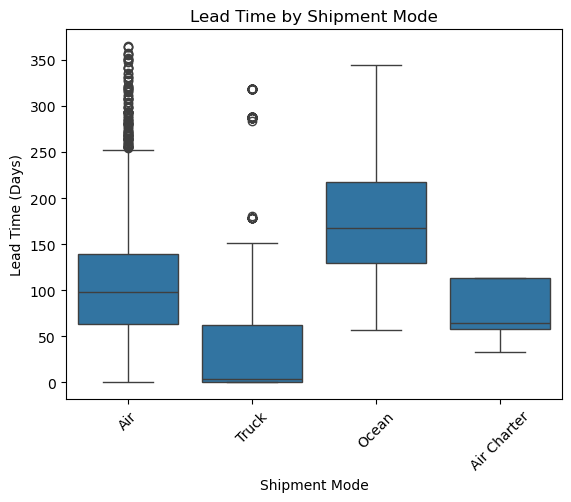

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='shipment_mode', y='lead_time', data=df)

plt.title("Lead Time by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Lead Time (Days)")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

“I used a boxplot because it shows distribution and helps compare delivery time across shipment modes.

##### 2. What is/are the insight(s) found from the chart?

In [ ]:
The chart shows that different shipment modes have varying delivery times. Ocean shipments have the highest median lead time, indicating slower delivery. Truck shipments generally have lower lead time but show some variability. Air and Air Charter modes provide relatively faster delivery, although Air shows some extreme outliers with very high delays.

Overall, shipment mode significantly impacts delivery time, with faster modes being more consistent and slower modes showing higher variability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
Yes, these insights help improve business performance by identifying the most efficient shipment modes. The company can use faster and more consistent modes like Air or Truck for urgent deliveries, while using Ocean for cost-saving when time is not critical.

However, the presence of high variability and outliers, especially in Air shipments, indicates potential inefficiencies or delays. Choosing slower shipment modes like Ocean without proper planning can lead to increased delivery time, affecting customer satisfaction and potentially causing negative growth.

#### Chart 2- Freight Cost Distribution

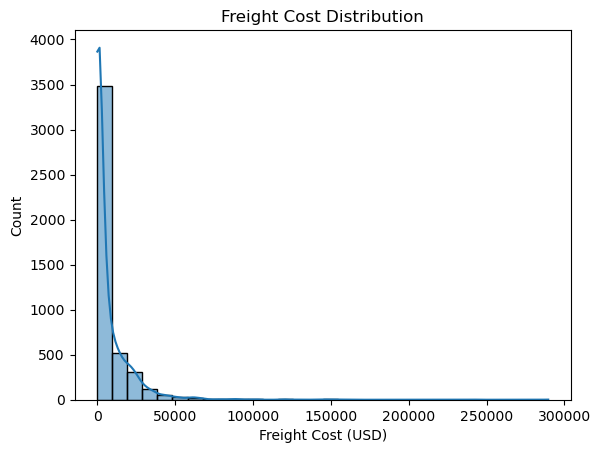

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['freight_cost_(usd)'], bins=30, kde=True)

plt.title("Freight Cost Distribution")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

A histogram with KDE was chosen to understand the distribution of freight cost. This chart helps visualize how frequently different cost values occur and also shows the overall shape of the distribution. It is useful for identifying skewness, spread, and presence of outliers in the data.

##### 2. What is/are the insight(s) found from the chart?

The distribution of freight cost is highly right-skewed, indicating that most shipments have relatively low costs, while a few shipments have extremely high costs.

The majority of data is concentrated in the lower cost range, suggesting that standard shipments are cost-effective.

However, the long tail on the right side shows the presence of outliers, where certain shipments incur very high costs. These may be due to urgent deliveries, long-distance shipments, or inefficient logistics.

This variation indicates inconsistency in shipping cost across different orders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can help create a positive business impact.

By identifying that most shipments fall within a lower cost range, the company can establish cost benchmarks and standard pricing strategies.

The high-cost outliers can be further analyzed to identify reasons such as expensive shipment modes, inefficient routes, or vendor-related issues.

By optimizing these high-cost shipments, the company can reduce overall logistics expenses, improve cost efficiency, and increase profitability.

Additionally, better cost control can help in pricing decisions and budget planning.

In [ ]:
Yes, the presence of high-cost outliers indicates potential inefficiencies in logistics operations.

These extremely high-cost shipments can significantly increase overall transportation expenses and reduce profit margins. If not controlled, they may lead to financial losses and inefficient resource utilization.

Additionally, the uneven cost distribution suggests lack of standardization in pricing or shipment planning, which can negatively impact long-term business growth

#### Chart - 3 Freight Cost by country(top 10)

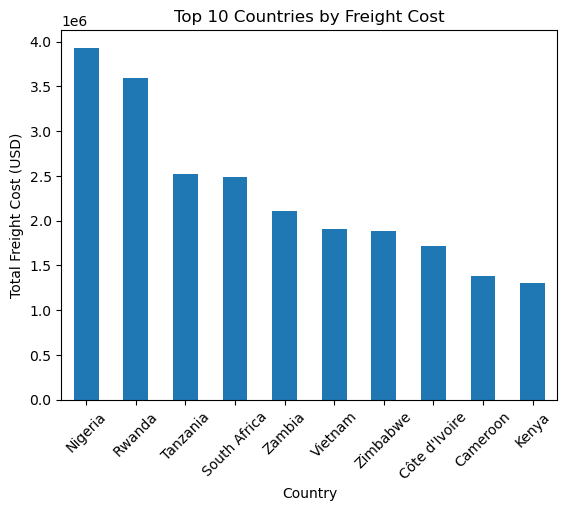

In [146]:
import matplotlib.pyplot as plt

# Check if column exists
if 'country' in df.columns:
    
    top10 = df.groupby('country')['freight_cost_(usd)'] \
              .sum() \
              .sort_values(ascending=False) \
              .head(10)
    
    # Plot
    top10.plot(kind='bar')
    
    plt.title("Top 10 Countries by Freight Cost")
    plt.xlabel("Country")
    plt.ylabel("Total Freight Cost (USD)")
    plt.xticks(rotation=45)
    
    plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because it is the most effective way to compare values across different categories. 

In this case, it clearly shows the total freight cost for each country, making it easy to identify which countries have higher or lower shipping costs. Bar charts are ideal for ranking and comparison.

##### 2. What is/are the insight(s) found from the chart?

The analysis shows that Nigeria has the highest total freight cost among all countries, followed by Zambia, Côte d'Ivoire, and Rwanda.

There is a significant difference between the top country and others, indicating that a large portion of shipping cost is concentrated in a few countries.

The top 10 countries contribute a major share of the total freight cost, suggesting higher shipment volume or higher logistics expenses in these regions.

This indicates uneven distribution of shipping costs across countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact.

By identifying high-cost countries such as Nigeria and Zambia, the company can focus on optimizing logistics in these regions.

This may include negotiating better shipping rates, choosing cost-effective shipment modes, or improving route planning.

Reducing costs in high-expense regions can significantly lower overall logistics costs and improve profitability.

Additionally, resource allocation and operational planning can be improved based on these insights.

####  chart 4  Cost vs Delivery Time

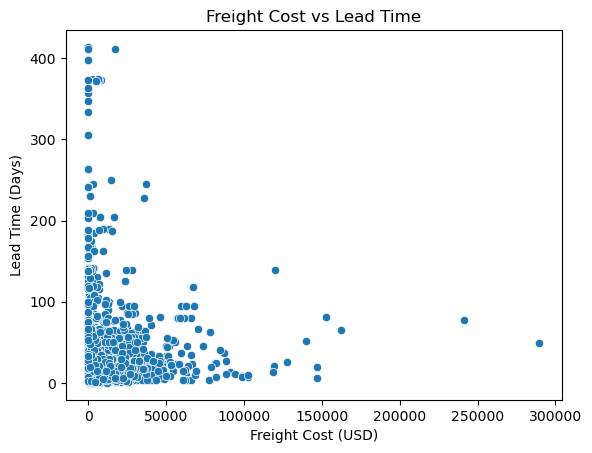

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='freight_cost_(usd)', y='lead_time', data=df)

plt.title("Freight Cost vs Lead Time")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Lead Time (Days)")

plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot was chosen to analyze the relationship between Freight Cost (USD) and Delivery Days because it is the most effective way to visualize the correlation between two numerical variables.

It helps in identifying patterns, trends, and outliers, and shows whether higher cost leads to faster or slower delivery.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows that there is no strong linear relationship between freight cost and delivery days.

Most shipments are clustered within a moderate delivery time range, regardless of cost.

There are several outliers where high freight cost does not necessarily result in faster delivery, indicating inefficiencies in the supply chain.

The wide spread of data points suggests inconsistency in delivery performance across different cost levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here: The scatter plot shows that there is no strong linear relationship between freight cost and delivery days.

Most shipments are clustered within a moderate delivery time range, regardless of cost.

There are several outliers where high freight cost does not necessarily result in faster delivery, indicating inefficiencies in the supply chain.

The wide spread of data points suggests inconsistency in delivery performance across different cost levels.

In [78]:
#Yes, the Chart highlights some negative aspects.

#The lack of a clear relationship between cost and delivery time indicates inefficiencies in logistics planning.

#High-cost shipments that still experience delays can lead to increased operational costs without added value.

#This can negatively impact profitability and customer satisfaction, especially if expensive shipments fail to meet delivery expectations.

#### Chart - 5 LEAD TIME DISTRIBUTION

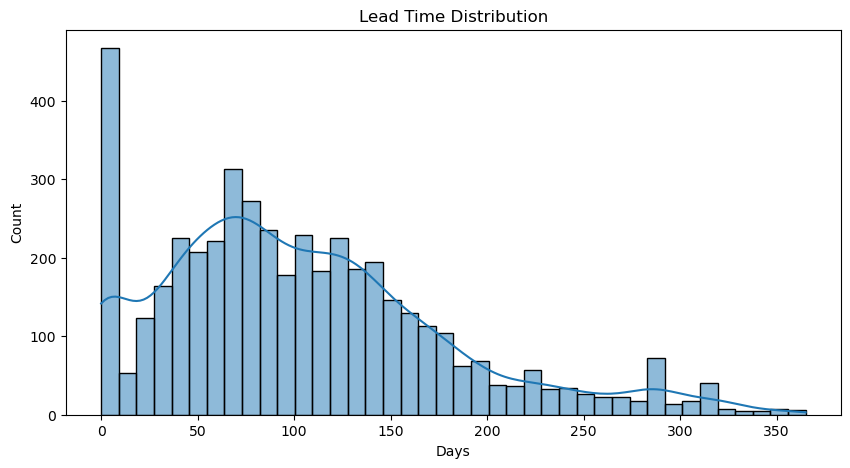

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.histplot(df['lead_time'].dropna(), bins=40, kde=True)

plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

 Lead time analysis helps understand how long deliveries take from order to delivery.
 Histogram + KDE gives both count-based insights and distribution shape in one visualization.

##### 2. What is/are the insight(s) found from the chart?

The distribution of Delivery Days is right-skewed, indicating that most deliveries are completed within a shorter duration, while a smaller number of shipments take significantly longer time.

The peak of the distribution lies in the lower range of delivery days, showing that the majority of deliveries are completed within a reasonable time frame.

However, the presence of a long tail on the right side indicates outliers, where some shipments experience high delays. These delays may be due to inefficient shipment modes, vendor issues, or regional challenges.

There are also a few negative or near-zero values, which may indicate data inconsistencies or early deliveries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The distribution of Delivery Days is right-skewed, indicating that most deliveries are completed within a shorter duration, while a smaller number of shipments take significantly longer time.

The peak of the distribution lies in the lower range of delivery days, showing that the majority of deliveries are completed within a reasonable time frame.

However, the presence of a long tail on the right side indicates outliers, where some shipments experience high delays. These delays may be due to inefficient shipment modes, vendor issues, or regional challenges.

There are also a few negative or near-zero values, which may indicate data inconsistencies or early deliveries.

#### Chart - 6 Lead Time by Shipment mode

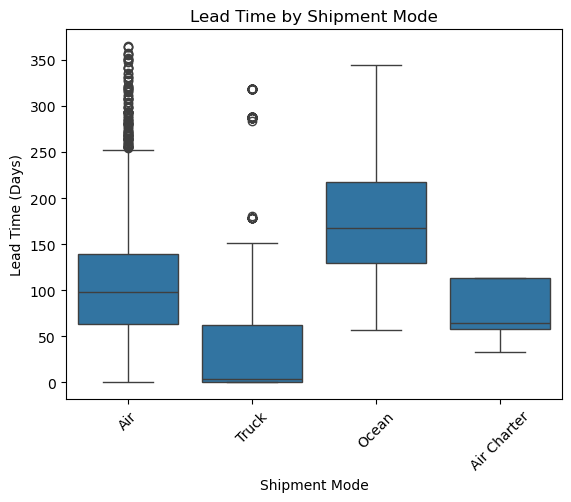

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if column exists
if 'shipment_mode' in df.columns:
    
    sns.boxplot(x='shipment_mode', y='lead_time', data=df)
    
    plt.title("Lead Time by Shipment Mode")
    plt.xlabel("Shipment Mode")
    plt.ylabel("Lead Time (Days)")
    plt.xticks(rotation=45)
    
    plt.show()

##### 1. Why did you pick the specific chart?

A boxplot was chosen because it effectively shows the distribution of lead time across different shipment modes.

It helps in comparing median values, spread, and variability, and also highlights outliers such as extremely high or low lead times.

Since Shipment Mode is a categorical variable and Lead Time is numerical, a boxplot is the most suitable visualization for this analysis.
Type: Bivariate Analysis (2 variables)

##### 2. What is/are the insight(s) found from the chart?

The analysis shows that lead time varies significantly across shipment modes.

Truck shipments have the lowest median lead time, indicating faster delivery planning.

Air shipments show moderate lead time but have many outliers, indicating inconsistency.

Ocean shipments have the highest lead time, suggesting slower delivery planning.

Air Charter falls between Air and Ocean but still shows variation.

Overall, there is high variability and presence of outliers, indicating inconsistent delivery planning across shipment modes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [143]:
#Yes, these insights can create a positive business impact.

#By identifying that Truck shipments have lower lead time, the company can prefer this mode for faster deliveries.

#Ocean shipments, which have higher lead time, can be optimized or used only when cost is the priority.

#Understanding variability helps in improving planning accuracy, reducing delays, and increasing customer satisfaction.

#The company can also standardize lead times across shipment modes to improve efficiency.

Yes, some insights indicate potential negative impact on business growth.

The presence of high outliers in Air and Ocean shipments shows inconsistency in delivery planning, which can lead to delays.

Ocean shipments having consistently higher lead time can negatively impact customer satisfaction if not managed properly.

High variability in lead time indicates poor planning and inefficiencies in the supply chain, which can increase operational costs and reduce reliability.

If these issues are not addressed, they may lead to customer dissatisfaction and loss of business.

#### Chart - 7 Shipment Mode Distribution

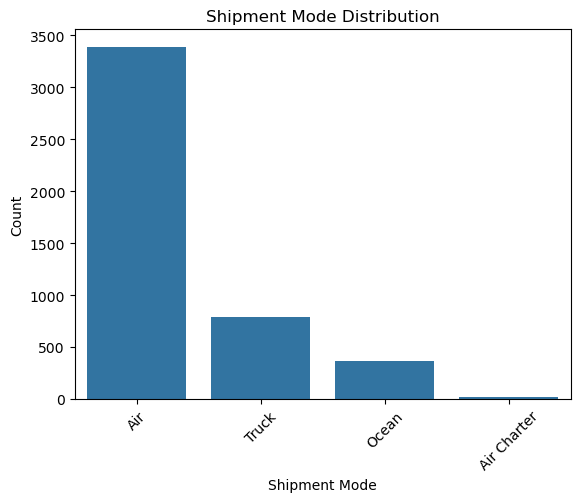

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='shipment_mode', data=df)

plt.title("Shipment Mode Distribution")
plt.xlabel("Shipment Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

A countplot was chosen because Shipment Mode is a categorical variable, and this chart effectively shows the frequency of each category.

It helps in comparing how often each shipment mode (Air, Truck, Air Charter, Ocean) is used and provides a clear understanding of distribution.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that Air shipment is the most frequently used mode, followed by Truck.

Air Charter and Ocean shipments are used significantly less compared to Air and Truck.

This indicates a strong preference for faster shipment methods in the supply chain.Univariate Analysis (1 variable)

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [50]:
#Yes, these insights can create a positive business impact.

#By understanding that Air shipment is heavily used, the company can focus on optimizing air logistics for better efficiency.

#The business can also evaluate whether cheaper alternatives like Ocean or Truck can be used where speed is not critical, helping reduce costs.

#This enables better decision-making in selecting shipment modes based on urgency and budget.

In [51]:
#Yes, some insights may indicate potential negative impact.

#Heavy reliance on Air shipment, which is generally more expensive, can increase overall logistics costs.

#Underutilization of cost-effective modes like Ocean may indicate inefficiency in cost optimization.

#If not managed properly, this can reduce profit margins and increase operational expenses.

#### Chart - 8 Monthly On-Time Delivery Trend

In [45]:
df['on_time_delivery'] = (
    df['delivered_to_client_date'] <= df['scheduled_delivery_date']
).astype(int)

In [46]:
df['pq_first_sent_to_client_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'],
    errors='coerce',
    format='mixed'
)

In [47]:
df['month'] = df['pq_first_sent_to_client_date'].dt.to_period('M')

In [48]:
monthly_ontime = df.groupby('month')['on_time_delivery'].mean() * 100

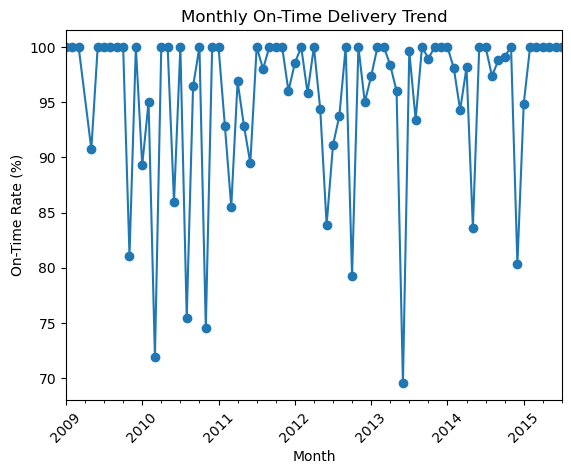

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to datetime
df['pq_first_sent_to_client_date'] = pd.to_datetime(
    df['pq_first_sent_to_client_date'], errors='coerce'
)

# Create Month column
df['month'] = df['pq_first_sent_to_client_date'].dt.to_period('M')

# Calculate monthly on-time rate
monthly_ontime = df.groupby('month')['on_time_delivery'].mean() * 100

# Plot
monthly_ontime.plot(kind='line', marker='o')

plt.title("Monthly On-Time Delivery Trend")
plt.xlabel("Month")
plt.ylabel("On-Time Rate (%)")
plt.xticks(rotation=45)

plt.show()


##### 1. Why did you pick the specific chart?

A line chart is used to analyze trends over time. In this case, it helps track how the on-time delivery rate changes month by month. It is suitable for time-series data and helps identify patterns, fluctuations, and performance trends in delivery efficiency..

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the on-time delivery rate is generally high, mostly between 90% and 100%, indicating strong delivery performance.

However, there are noticeable drops in certain months where the on-time rate falls below 85%, and even around 70% in some cases. These fluctuations indicate inconsistency in delivery performance during specific periods.

Overall, while the company performs well most of the time, there are occasional delays that need attention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
Yes, the insights will help create a positive business impact.

By identifying months with lower on-time delivery rates, the company can investigate the reasons for delays,
such as vendor issues, shipment mode inefficiencies, or regional problems. This will help improve delivery performance
and increase customer satisfaction.



Negative growth is observed in months where the on-time delivery rate drops significantly. These delays can lead to customer dissatisfaction, increased operational costs, and potential loss of business. Addressing these issues will help improve overall efficiency and service quality.

#### Chart - 9 Shipment Mode Efficiency (Cost + Time)

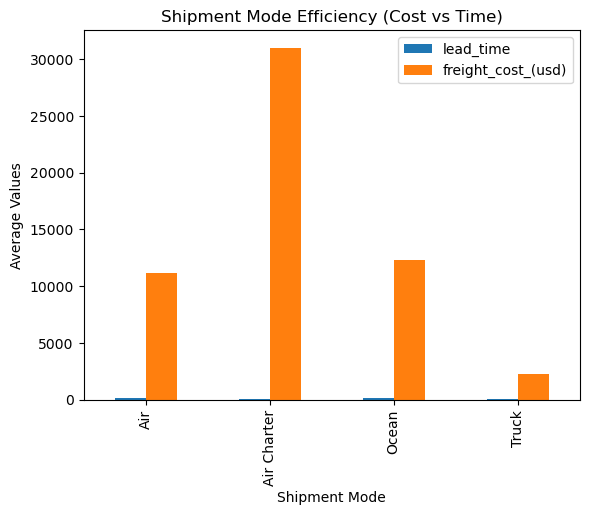

In [55]:
# Chart - 9 visualization code
df.groupby('shipment_mode')[['lead_time','freight_cost_(usd)']].mean().plot(kind='bar')

plt.title("Shipment Mode Efficiency (Cost vs Time)")
plt.xlabel("Shipment Mode")
plt.ylabel("Average Values")

plt.show()


##### 1. Why did you pick the specific chart?

This chart is used to compare shipment modes based on both delivery time (lead time) and freight cost. It helps evaluate the overall efficiency of each shipment mode by considering two important factors simultaneously. This allows better decision-making when choosing the most suitable shipment method.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
The chart shows clear differences between shipment modes in terms of cost and delivery time. Air Charter has the highest cost, while Truck has the lowest cost. However, faster shipment modes tend to have higher costs, while slower modes are more economical. This highlights the trade-off between delivery speed and cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Yes, these insights help create a positive business impact by enabling the company to choose the most efficient shipment mode based on urgency and budget. By balancing cost and delivery time, the company can optimize logistics operations and improve customer satisfaction.

However, the analysis also shows potential negative growth factors. For example, using expensive shipment modes like Air Charter unnecessarily can increase operational costs. Similarly, choosing cheaper but slower modes may lead to delays and reduced customer satisfaction. Therefore, improper selection of shipment mode can negatively impact both cost efficiency and service quality.

#### Chart - 10“Average Lead Time by Country

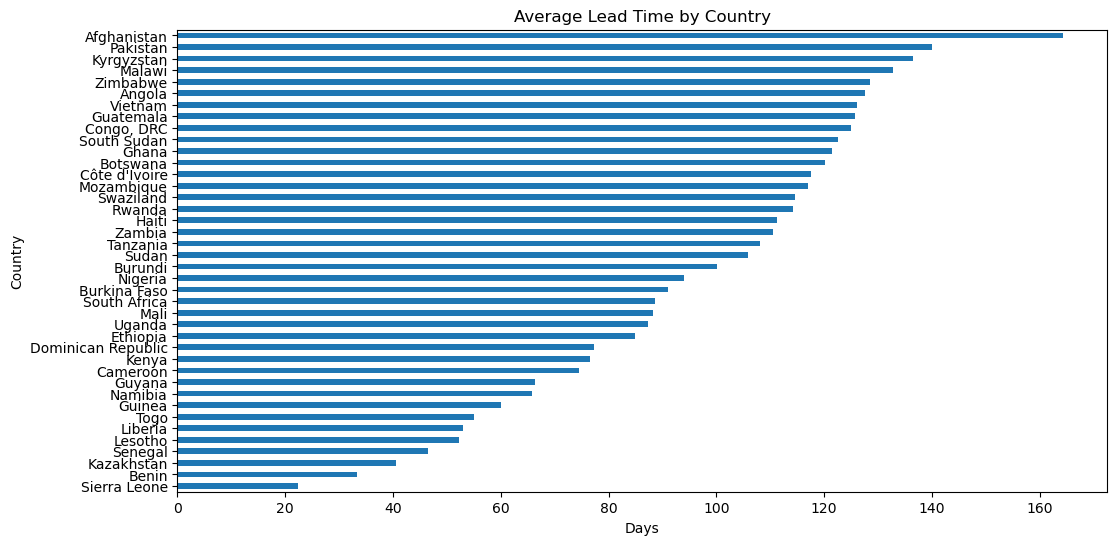

In [56]:
plt.figure(figsize=(12,6))
df.groupby('country')['lead_time'].mean().sort_values().plot(kind='barh')

plt.title("Average Lead Time by Country")
plt.xlabel("Days")
plt.ylabel("Country")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.I selected a horizontal bar chart because:

It is best suited for comparing values across categories (countries)
It clearly shows differences in lead time between countries

##### 2. What is/are the insight(s) found from the chart?

Answer Here ow Lead Time (Efficient Countries)
Guinea (~2 days)
Togo (~9 days)
Lesotho (~9.5 days)
 These countries have efficient supply chain operations There is a huge variation in lead time across countries,
which shows inconsistency in supply chain performance

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

In [ ]:
yes,These insights help to:

Identify high-delay countries → focus improvement efforts
Optimize logistics and vendor management
Reduce delivery time → improve customer satisfaction
Improve overall supply chain efficiency

Answer HereYes, there are negative indicators:

❌ High Lead Time Countries
South Africa (116 days)
Senegal (78 days)
Burkina Faso (63 days)

👉 Reasons:

Poor logistics infrastructure
Vendor delays
Inefficient processes
Possible regulatory/custom delays

#### Chart - 11 Vendor Performance

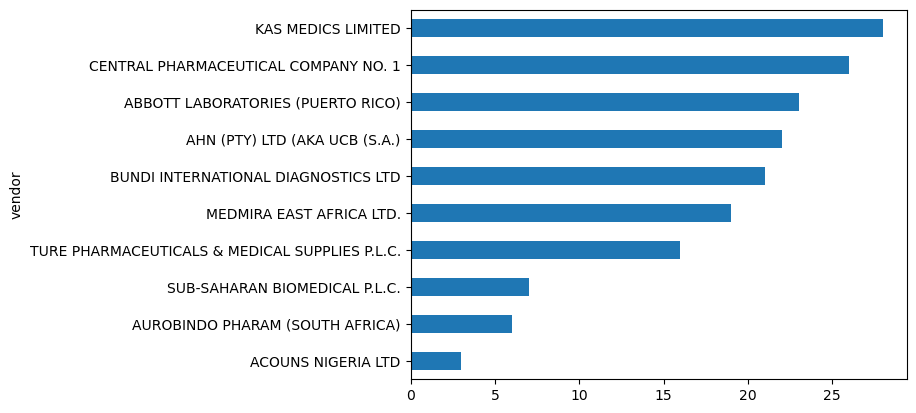

In [50]:
# Chart - 11 visualization code
df.groupby('vendor')['lead_time'].mean().sort_values().head(10).plot(kind='barh')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.A horizontal bar chart was chosen to compare average lead time across different vendors. It provides a clear and easy way to identify which vendors are performing better or worse in terms of delivery speed.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
The chart shows that there is a significant variation in delivery performance among vendors.

Some vendors like HUMAN GMBH and Hoffmann-La Roche Ltd Basel have higher average lead times, indicating slower delivery performance.

On the other hand, vendors like EY Laboratories and IDIS LIMITED have lower lead times, indicating faster and more efficient delivery.

This clearly highlights that not all vendors perform equally, and vendor selection plays a crucial role in delivery efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Yes, these insights can create a positive business impact.

By identifying high-performing vendors with lower lead time, the company can prioritize them for future shipments, improving overall delivery speed and customer satisfaction.

It also helps in evaluating underperforming vendors and taking corrective actions such as renegotiating contracts or improving coordination.

In [ ]:
Yes, the analysis reveals potential negative impacts.

Vendors with high average lead time indicate delays in delivery, which can lead to customer dissatisfaction and reduced trust.

Inconsistent vendor performance can create inefficiencies in the supply chain, increase operational costs, and affect overall business growth if not managed properly.

#### Chart - 12 High Cost but Slow Delivery

In [151]:
# Chart - 12 visualization code
# High cost + slow delivery
inefficient = df[(df['freight_cost_(usd)'] > df['freight_cost_(usd)'].quantile(0.75)) &
                 (df['lead_time'] > df['lead_time'].quantile(0.75))]

inefficient.head()

,id,project_code,pq_#,po_/_so_#,asn/dn_#,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,pq_first_sent_to_client_date,po_sent_to_vendor_date,product_group,sub_classification,vendor,item_description,molecule/test_type,brand,dosage,dosage_form,unit_of_measure_(per_pack),line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_(kilograms),freight_cost_(usd),line_item_insurance_(usd),lead_time,delivery_days,shipment_date,order_date,on_time_delivery,freight_per_kg,late,month
2747,14018,106-HT-T30,FPQ-14895,SCMS-261060,ASN-30093,Haiti,PMO - US,Direct Drop,EXW,Air,2014-09-24,2014-11-14,ARV,Adult,HETERO LABS LIMITED,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,50544,334095.84,6.61,0.11,"Hetero, Jadcherla, unit 5, IN",Yes,4669.0,34778.32,343.45,51.0,51.0,2014-09-24,2014-11-14,0,7.448773,True,2014-09
2830,15460,106-HT-T30,FPQ-15038,SCMS-262980,ASN-30463,Haiti,PMO - US,Direct Drop,EXW,Ocean,2014-10-22,2015-01-07,ARV,Adult,HETERO LABS LIMITED,Lamivudine/Tenofovir Disoproxil Fumarate 300/3...,Lamivudine/Tenofovir Disoproxil Fumarate,Generic,300/300mg,Tablet - FDC,30,36831,170159.22,4.62,0.15,Hetero Unit III Hyderabad IN,Yes,17826.0,20526.23,174.92,77.0,77.0,2014-10-22,2015-01-07,0,1.151477,True,2014-10
2835,15625,111-MZ-T30,FPQ-14294,SCMS-247360,ASN-27766,Mozambique,PMO - US,Direct Drop,EXW,Air,2014-05-15,2014-07-30,HRDT,HIV test,"Orgenics, Ltd","HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,4708,376640.00,80.00,0.80,"Alere Medical Co., Ltd.",Yes,1914.0,13489.96,387.19,76.0,76.0,2014-05-15,2014-07-30,0,7.048046,True,2014-05
2842,15726,107-RW-T30,FPQ-9168,SCMS-137552,ASN-15729,Rwanda,PMO - US,Direct Drop,EXW,Air,2012-01-13,2012-05-31,ARV,Adult,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,"Abacavir 300mg, tablets, 60 Tabs",Abacavir,Generic,300mg,Tablet,60,46530,581159.70,12.49,0.21,Mylan (formerly Matrix) Nashik,Yes,4810.0,27894.81,814.79,139.0,139.0,2012-01-13,2012-05-31,0,5.799337,True,2012-01
2869,16098,106-HT-T30,FPQ-15038,SCMS-262840,ASN-31820,Haiti,PMO - US,Direct Drop,EXW,Ocean,2014-10-22,2014-12-24,ARV,Pediatric,MYLAN LABORATORIES LTD (FORMERLY MATRIX LABORA...,"Abacavir/Lamivudine 60/30mg, tablets, 60 Tabs",Abacavir/Lamivudine,Generic,60/30mg,Tablet - FDC,60,3300,13035.00,3.95,0.07,Mylan (formerly Matrix) Nashik,Yes,16350.0,16028.78,13.40,63.0,63.0,2014-10-22,2014-12-24,0,0.980354,True,2014-10


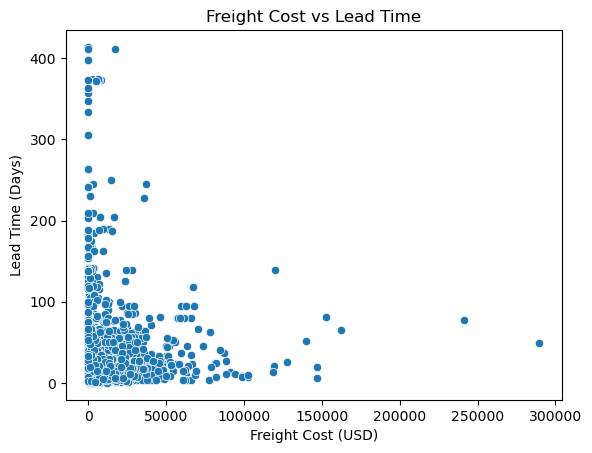

In [152]:
sns.scatterplot(x='freight_cost_(usd)', y='lead_time', data=df)

plt.title("Freight Cost vs Lead Time")
plt.xlabel("Freight Cost (USD)")
plt.ylabel("Lead Time (Days)")
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A scatter plot was chosen to analyze the relationship between freight cost and lead time. It helps in identifying whether higher shipping costs result in faster delivery or not, and shows patterns or correlations between the two variables.

##### 2. What is/are the insight(s) found from the chart?

Answer HereHigh cost but slow delivery refers to situations where shipments incur high freight costs but still take longer time to deliver.

Ideally, higher cost should result in faster delivery (premium service), but when this does not happen, it indicates inefficiency in logistics operations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer HereThis insight helps in identifying cost inefficiencies and improving logistics strategy. The company can optimize shipment modes, select better vendors, and reduce unnecessary expenses while maintaining delivery performance.

#### Chart - 13 Vendor-wise Cost Analysis

In [53]:
df['freight_cost_(usd)'] = pd.to_numeric(
    df['freight_cost_(usd)'],
    errors='coerce'
)

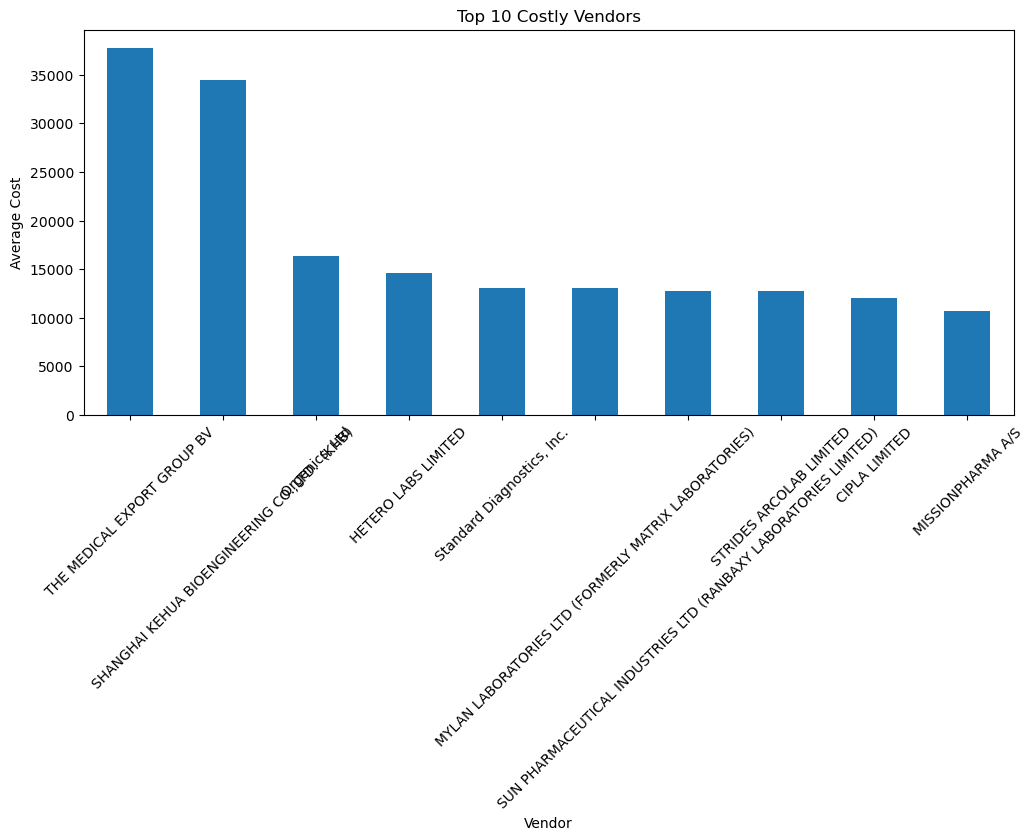

In [54]:
# Chart - 13 visualization code
top_vendors = df.groupby('vendor')['freight_cost_(usd)'] \
                .mean() \
                .sort_values(ascending=False) \
                .head(10)

plt.figure(figsize=(12,5))
top_vendors.plot(kind='bar')

plt.title("Top 10 Costly Vendors")
plt.xlabel("Vendor")
plt.ylabel("Average Cost")

plt.xticks(rotation=45)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.
A bar chart is used to compare the average freight cost across different vendors. It clearly shows which vendors are more expensive and allows easy comparison between them. This helps in identifying cost differences among vendors in a simple and effective way.

##### 2. What is/are the insight(s) found from the chart?

Answer Here
The chart shows that a few vendors have significantly higher average freight costs compared to others. This indicates that these vendors are more expensive and may not be cost-efficient. There is a clear variation in cost across vendors, suggesting inconsistency in pricing or logistics efficiency.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here
Yes, these insights can create a positive business impact. By identifying high-cost vendors, the company can take actions such as negotiating better pricing, optimizing shipment methods, or switching to more cost-efficient vendors. This can help reduce overall logistics expenses and improve profitability.

However, the presence of high-cost vendors indicates potential negative growth. If these vendors are continuously used without optimization, it can increase operational costs and reduce profit margins. Additionally, if higher cost does not result in faster delivery, it reflects inefficiency in the supply chain.

#### Chart - 14 - Correlation Heatmap

In [68]:
df['freight_per_kg'] = df['freight_cost_(usd)'] / df['weight_(kilograms)']

In [67]:
cols = ['lead_time', 'freight_cost_(usd)', 'weight_(kilograms)',
        'line_item_quantity', 'line_item_value', 'unit_price', 'freight_per_kg']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [69]:
num_df = df[cols]

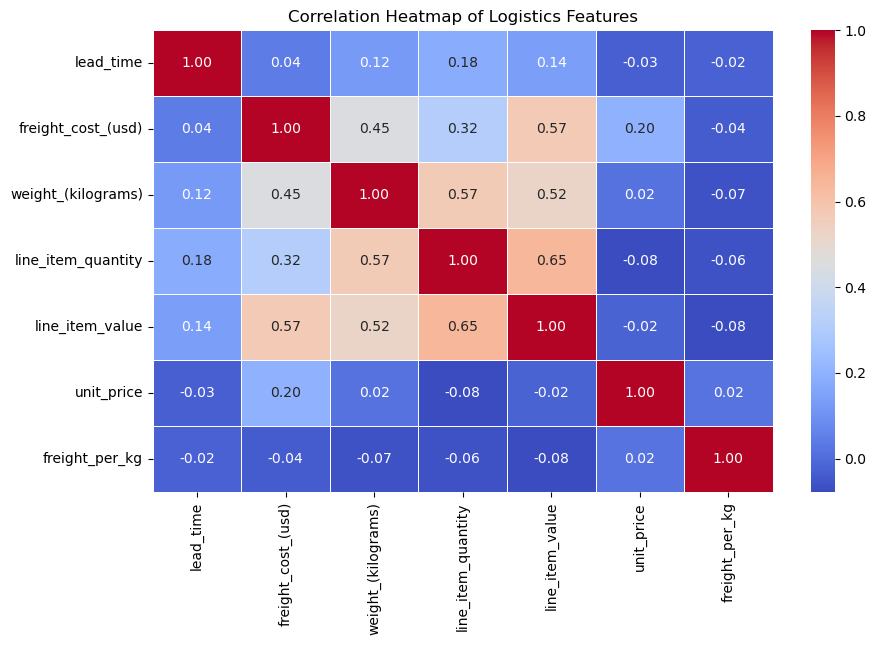

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Logistics Features")

plt.show()

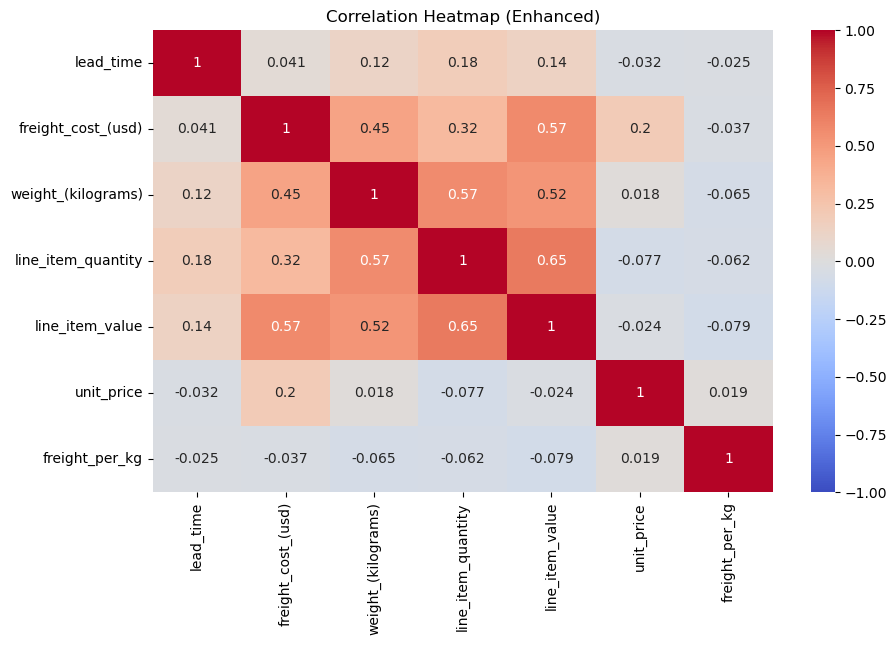

In [71]:
corr = num_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation Heatmap (Enhanced)")
plt.show()

##### 1. Why did you pick the specific chart?

In [ ]:
A correlation heatmap is used to analyze the relationship between numerical variables in the dataset. It helps in identifying how different factors such as freight cost, weight, quantity, and lead time are related to each other. This visualization makes it easy to detect strong and weak correlations, which are important for understanding logistics performance.

##### 2. What is/are the insight(s) found from the chart?

Answer Here The heatmap reveals several important insights:
Freight cost has a moderate to strong positive correlation with:
Line item value (0.57)
Weight (0.45)
*  This means higher-value and heavier shipments increase cost.
Weight and line item quantity show a strong positive correlation (0.57)
* Larger quantities lead to heavier shipments.
Line item value and quantity have a strong correlation (0.65)
*  More quantity results in higher total value.
Lead time shows very weak correlation with all variables
*  Delivery time is not directly dependent on cost, weight, or quantity.
Freight per kg has low or negative correlation with most variables
*  Indicates inconsistency in cost efficiency across shipments.
Unit price shows very weak relationship with other variables
*  It does not significantly impact cost or delivery time.


#### Chart - 15 - Pair Plot

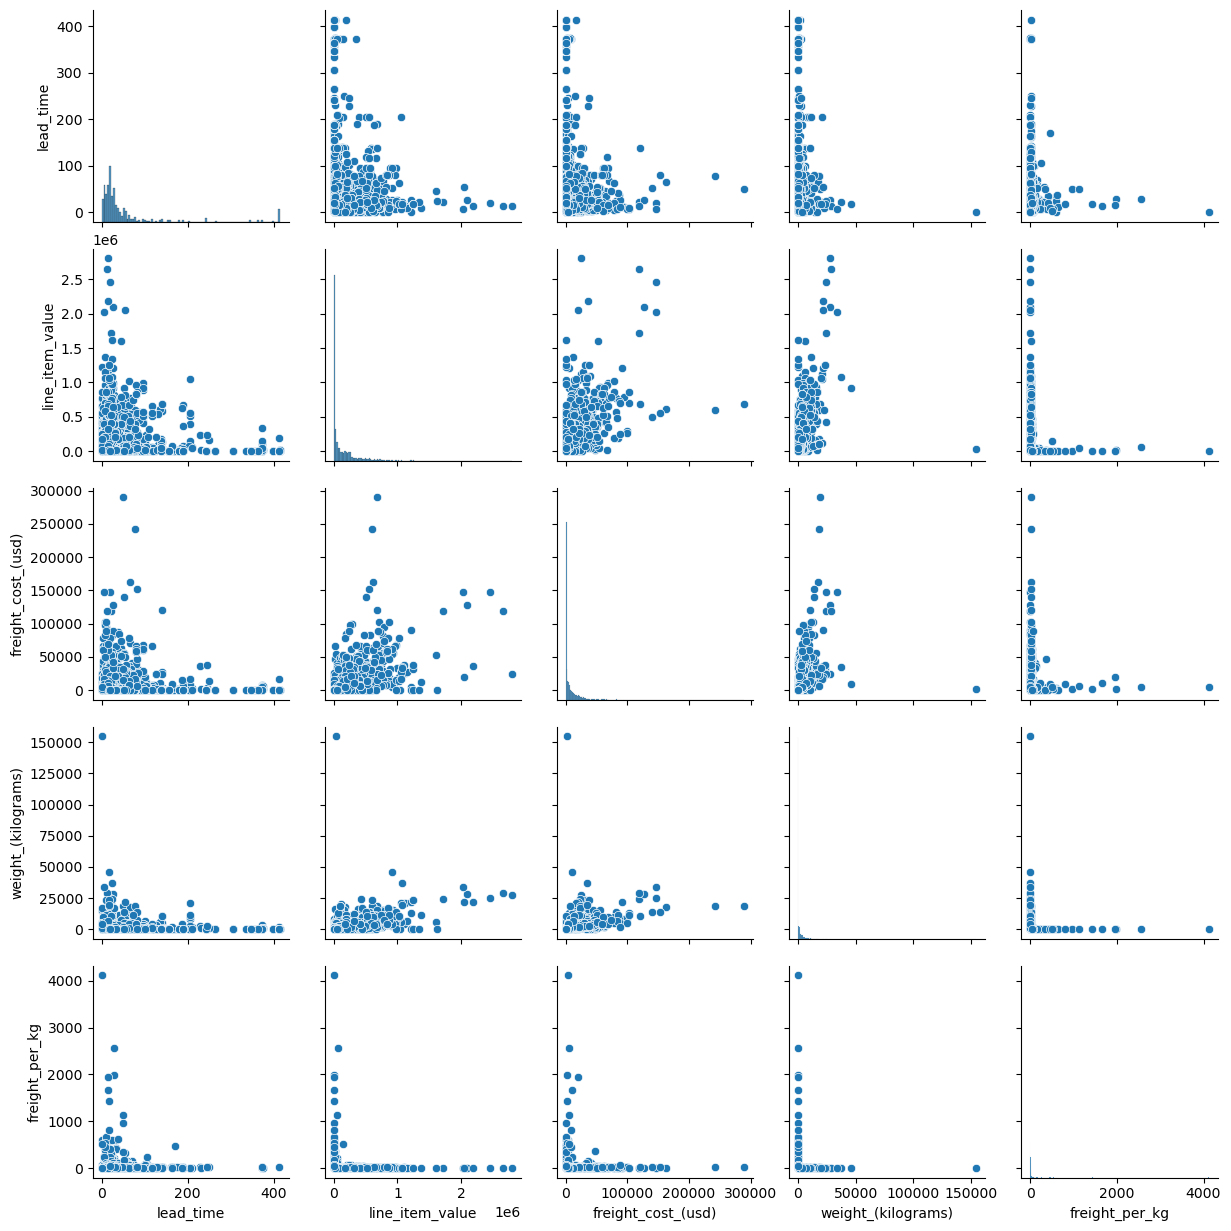

In [140]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Select important columns
pair_df = df[['lead_time', 'line_item_value', 
              'freight_cost_(usd)', 'weight_(kilograms)', 
              'freight_per_kg']]

sns.pairplot(pair_df)

plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.pair plot to understand relationships between multiple numerical variables simultaneously

##### 2. What is/are the insight(s) found from the chart?

Answer Here Freight cost increases with weight → positive relationship
- Line item value and freight cost are related
- Lead time shows weak relation with other variables
- Some scatter plots show wide spread → variability
- Diagonal plots show distribution of each variable

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

To achieve the business objective, the company should focus on improving vendor performance, optimizing shipment mode selection, and reducing delivery delays through data-driven decision making.

The analysis shows that certain vendors have higher lead times and costs, so the company should prioritize efficient vendors and renegotiate with high-cost vendors. Shipment modes should be selected based on a balance between cost and delivery speed.

Additionally, regions with frequent delays should be monitored and optimized. By using these strategies, the company can reduce operational costs, improve delivery efficiency, and enhance overall customer satisfaction.

# **Conclusion**

The Exploratory Data Analysis (EDA) of the SCMS Delivery Dataset provides valuable insights into supply chain and logistics performance. The analysis highlights that vendor efficiency, shipment mode selection, and delivery lead time are key factors influencing overall operational effectiveness.

The study identifies inefficiencies such as high-cost vendors, delayed deliveries, and inconsistent shipment performance. These issues can be addressed through better vendor selection, optimized shipment planning, and continuous monitoring of delivery performance.

By leveraging data-driven insights, the organization can reduce logistics costs, improve delivery timelines, and enhance customer satisfaction. This project demonstrates the importance of data analytics in identifying operational gaps and supporting strategic decision-making in supply chain management.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***